# 03 · Exploratory data analysis

Questions: which skills are in demand, how requirements differ by seniority and location, and what salary patterns exist.

Data: `data/processed/jobs.parquet` (10,040 US-heavy tech postings, almost all listed in April 2024).
Skills come from our regex extractor (`src/features/skills.py`) run on title + description. Percentages are *share of postings that mention the skill*.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

from src import viz
from src.features.skills import SKILL_NAMES, skill_column, skill_matrix
from src.features.text import extract_years

viz.set_style()
df = pd.read_parquet(ROOT / "data" / "processed" / "jobs.parquet")

# The skill matrix takes ~1-2 min, so it is cached next to jobs.parquet (git-ignored).
skills_path = ROOT / "data" / "processed" / "skills.parquet"
if skills_path.exists():
    skills = pd.read_parquet(skills_path)
    assert skills.index.equals(df.index)
else:
    skills = skill_matrix(df["title"] + " " + df["description_clean"])
    skills.to_parquet(skills_path)

name_of = {skill_column(n): n for n in SKILL_NAMES}
S = skills.drop(columns="skill_count").rename(columns=name_of)
df["skill_count"] = skills["skill_count"]
df["years_required"] = df["description_clean"].map(extract_years)
df["desc_words"] = df["description_clean"].str.split().str.len()
labeled = df["seniority"].notna()
LEVELS = viz.SENIORITY_ORDER
print(f"{len(df):,} postings, {labeled.sum():,} with a seniority label, {df['salary_yearly'].notna().sum():,} with salary")

10,040 postings, 7,108 with a seniority label, 2,899 with salary


## 1. Skills

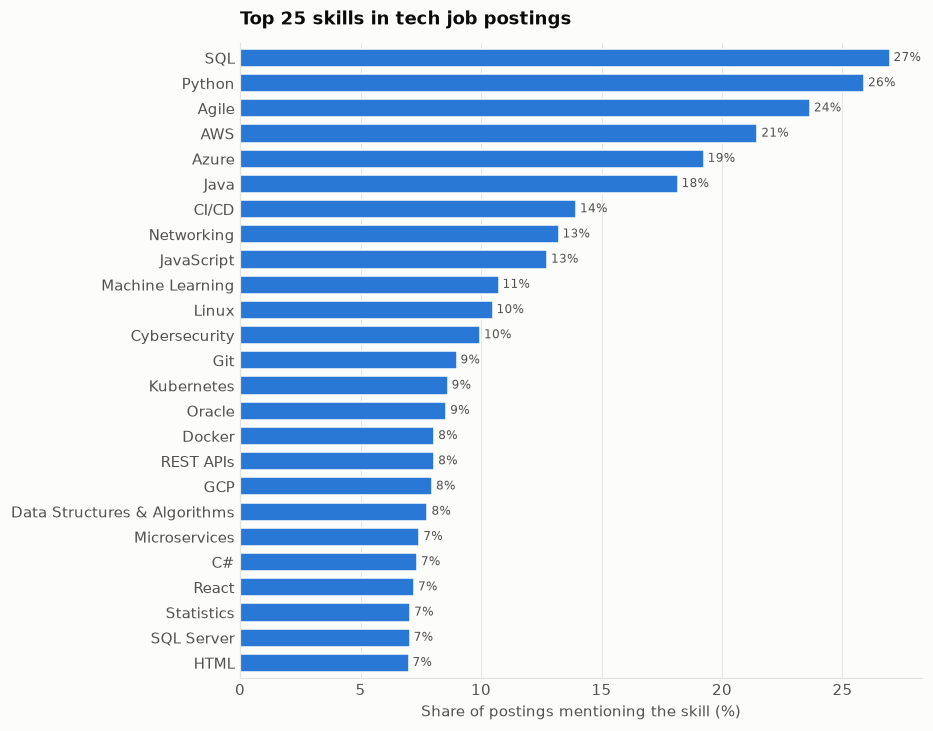

In [2]:
top25 = (S.mean() * 100).sort_values(ascending=False).head(25)
fig, ax = plt.subplots(figsize=(8, 7.5))
viz.barh(ax, top25.index, top25.values, fmt="{:.0f}%")
ax.set_title("Top 25 skills in tech job postings")
ax.set_xlabel("Share of postings mentioning the skill (%)")
viz.save(fig, "01_top_skills")
plt.show()

**Takeaway:** SQL (27%) and Python (26%) are the most-requested skills, ahead of any framework. Cloud platforms (AWS 21%, Azure 19%) outrank every frontend technology, and React appears in only 7% of tech postings.

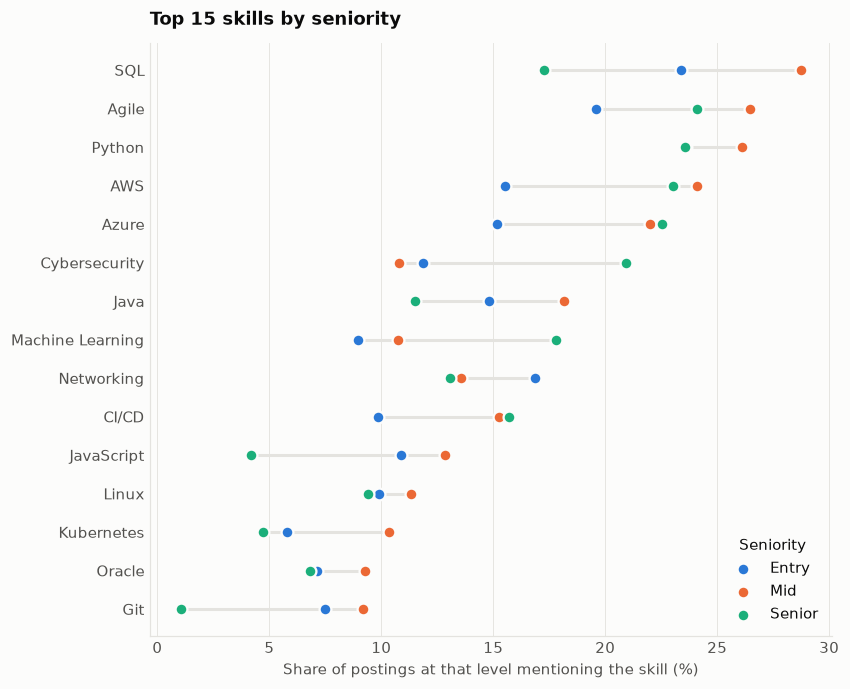

seniority,Entry,Mid,Senior
SQL,23.4,28.7,17.3
Python,23.6,26.1,23.6
Agile,19.6,26.5,24.1
AWS,15.5,24.1,23.0
Azure,15.2,22.0,22.5
Java,14.8,18.2,11.5
CI/CD,9.8,15.2,15.7
Networking,16.9,13.6,13.1
JavaScript,10.9,12.8,4.2
Machine Learning,8.9,10.8,17.8


In [3]:
top15 = top25.index[:15]
by_level = S.loc[labeled, top15].groupby(df.loc[labeled, "seniority"], observed=True).mean().mul(100).reindex(LEVELS)
order = by_level.max().sort_values().index  # smallest at bottom

fig, ax = plt.subplots(figsize=(8, 7))
y = np.arange(len(order))
ax.hlines(y, by_level[order].min(), by_level[order].max(), color=viz.GRID, linewidth=2, zorder=1)
for level in LEVELS:
    ax.scatter(by_level.loc[level, order], y, s=60, color=viz.SENIORITY_COLORS[level],
               edgecolor=viz.SURFACE, linewidth=1.5, label=level, zorder=2)
ax.set_yticks(y, order)
ax.grid(axis="y", visible=False)
ax.set_title("Top 15 skills by seniority")
ax.set_xlabel("Share of postings at that level mentioning the skill (%)")
ax.legend(title="Seniority", loc="lower right")
viz.save(fig, "02_skills_by_seniority")
plt.show()
by_level.T.round(1)

**Takeaway:** Entry postings over-index on Networking (17% vs. 13–14%), which reflects the IT-support roles in that class. Senior (director/executive) postings lean towards Cybersecurity (21%) and Machine Learning (18%), and rarely name hands-on tools like Git (1%) or JavaScript (4%).

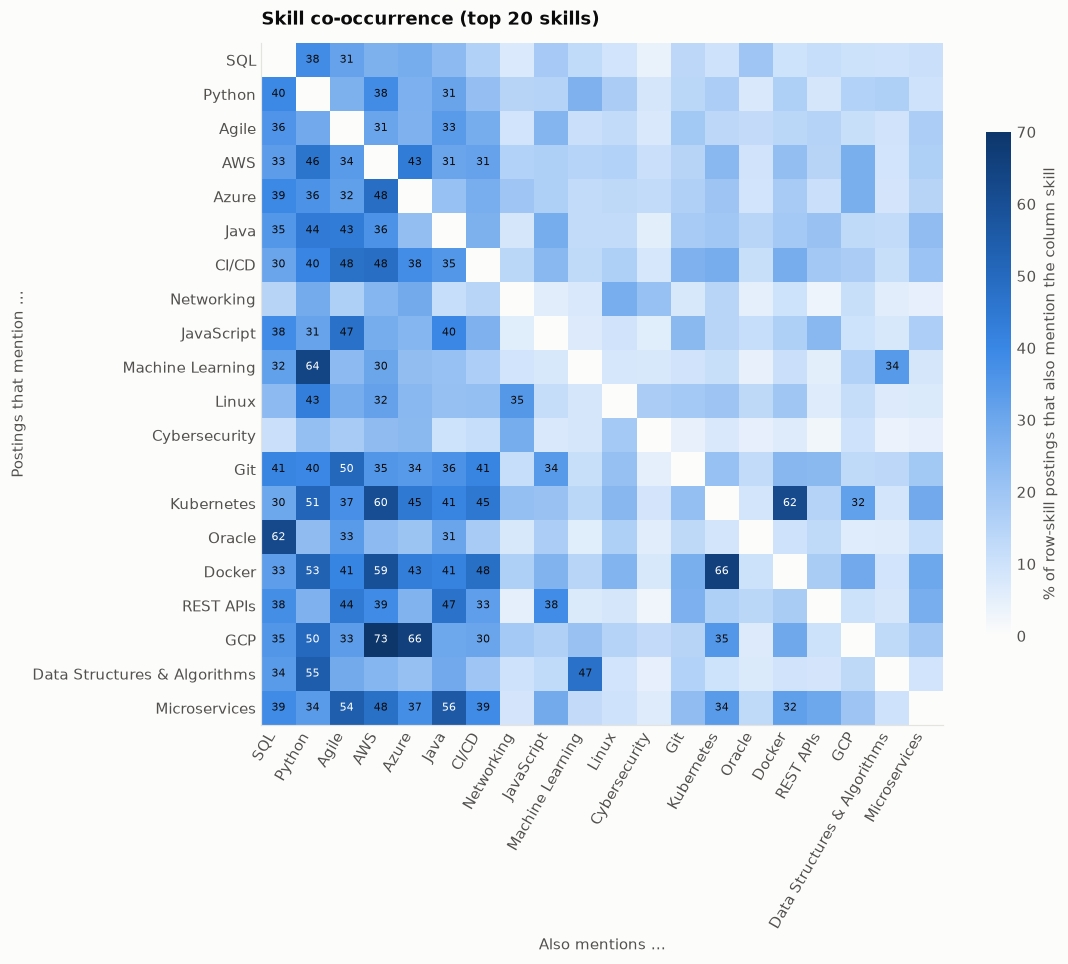

In [4]:
top20 = top25.index[:20]
X = S[top20].to_numpy(dtype=float)
co = X.T @ X
cond = co / np.diag(co)[:, None] * 100  # row skill -> % of those postings that also mention the column skill
np.fill_diagonal(cond, np.nan)

fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(cond, cmap=viz.SEQUENTIAL, vmin=0, vmax=70)
ax.set_xticks(range(20), top20, rotation=60, ha="right")
ax.set_yticks(range(20), top20)
ax.grid(False)
for i in range(20):
    for j in range(20):
        if i != j and cond[i, j] >= 30:
            ax.text(j, i, f"{cond[i, j]:.0f}", ha="center", va="center", fontsize=7,
                    color="white" if cond[i, j] >= 50 else viz.TEXT_PRIMARY)
cbar = fig.colorbar(im, ax=ax, shrink=0.7)
cbar.set_label("% of row-skill postings that also mention the column skill")
cbar.outline.set_visible(False)
ax.set_title("Skill co-occurrence (top 20 skills)")
ax.set_xlabel("Also mentions ...")
ax.set_ylabel("Postings that mention ...")
viz.save(fig, "03_skill_cooccurrence")
plt.show()

**Takeaway:** Skills come in stacks. 66% of Docker postings also mention Kubernetes. 73% of GCP postings also mention AWS, so employers want multi-cloud. 64% of Machine Learning postings mention Python, and 62% of Oracle postings mention SQL.

## 2. Seniority

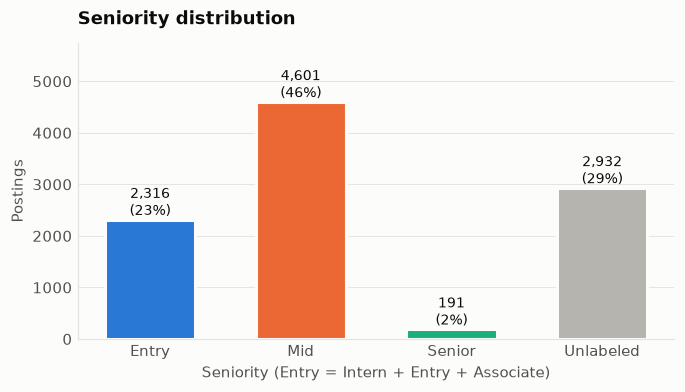

In [5]:
counts = df["seniority"].value_counts().reindex(LEVELS)
counts["Unlabeled"] = df["seniority"].isna().sum()
colors = [viz.SENIORITY_COLORS[l] for l in LEVELS] + ["#b5b4af"]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(counts.index, counts.values, color=colors, width=0.6, edgecolor=viz.SURFACE, linewidth=2)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}\n({v / len(df):.0%})", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.25)
ax.grid(axis="x", visible=False)
ax.set_title("Seniority distribution")
ax.set_xlabel("Seniority (Entry = Intern + Entry + Associate)")
ax.set_ylabel("Postings")
viz.save(fig, "04_seniority_distribution")
plt.show()

**Takeaway:** Mid is the largest class (46%). Senior is only 2% (191 postings), and 29% of postings have no label. The classifier has to handle heavy imbalance, and the unlabeled rows can only be used for EDA and clustering.

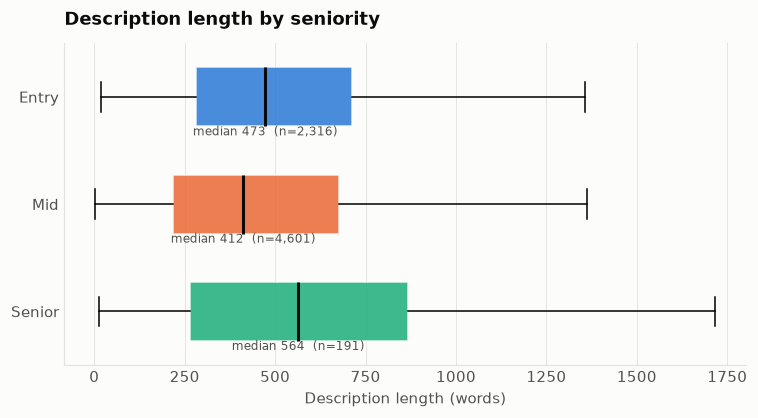

In [6]:
def box_by_level(ax, column, xlabel):
    data = [df.loc[df["seniority"].eq(l), column].dropna() for l in LEVELS]
    bp = ax.boxplot(data, orientation="horizontal", tick_labels=LEVELS, showfliers=False, patch_artist=True,
                    widths=0.55, medianprops={"color": viz.TEXT_PRIMARY, "linewidth": 2})
    for patch, level in zip(bp["boxes"], LEVELS):
        patch.set(facecolor=viz.SENIORITY_COLORS[level], alpha=0.85, edgecolor=viz.SURFACE)
    for level, d in zip(LEVELS, data):
        ax.text(d.median(), LEVELS.index(level) + 1.36, f"median {d.median():,.0f}  (n={len(d):,})",
                ha="center", fontsize=8, color=viz.TEXT_SECONDARY)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    ax.set_xlabel(xlabel)


fig, ax = plt.subplots(figsize=(8, 3.8))
box_by_level(ax, "desc_words", "Description length (words)")
ax.set_title("Description length by seniority")
viz.save(fig, "05_description_length")
plt.show()

**Takeaway:** Description length barely separates the levels (medians of 473 / 412 / 564 words), so length alone will be a weak feature. Director-level postings are only somewhat longer.

           coverage  median
seniority                  
Entry          0.60     3.0
Mid            0.68     5.0
Senior         0.73     5.0


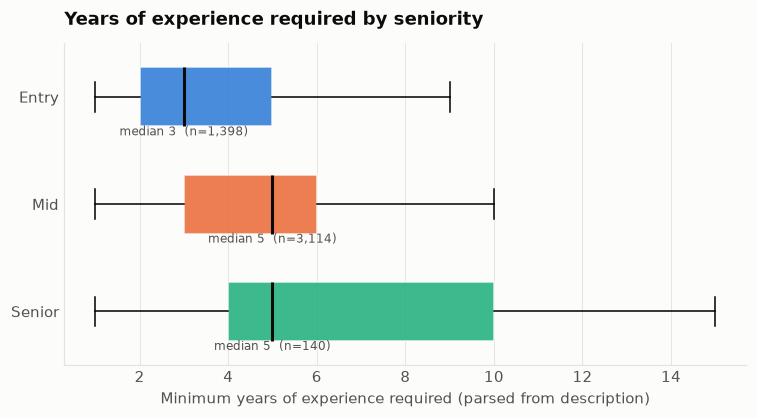

In [7]:
print(df.groupby("seniority", observed=True)["years_required"].agg(coverage=lambda s: s.notna().mean(), median="median").round(2))
fig, ax = plt.subplots(figsize=(8, 3.8))
box_by_level(ax, "years_required", "Minimum years of experience required (parsed from description)")
ax.set_title("Years of experience required by seniority")
viz.save(fig, "06_years_required")
plt.show()

**Takeaway:** Required experience rises from a median of 3 years (Entry) to 5 years (Mid and Senior). Even Entry postings often ask for 2–5 years, partly because Associate roles are included. The parser finds a number in 60–73% of postings.

## 3. Location and remote work

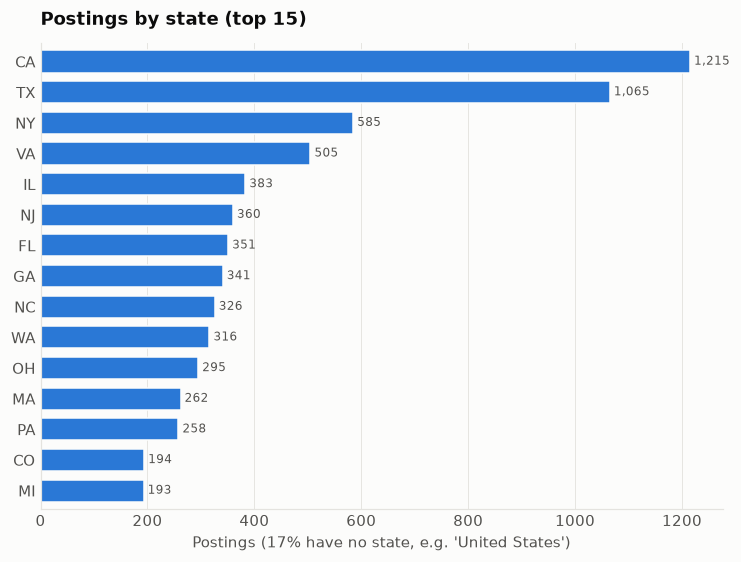

In [8]:
state_counts = df["state"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(8, 5.5))
viz.barh(ax, state_counts.index, state_counts.values, fmt="{:,.0f}")
ax.set_title("Postings by state (top 15)")
ax.set_xlabel(f"Postings ({df['state'].isna().mean():.0%} have no state, e.g. 'United States')")
viz.save(fig, "07_postings_by_state")
plt.show()

**Takeaway:** California (1,215) and Texas (1,065) hold 23% of all tech postings. Virginia ranks 4th (505), ahead of Illinois, likely because of government and defense contractors around Washington, DC.

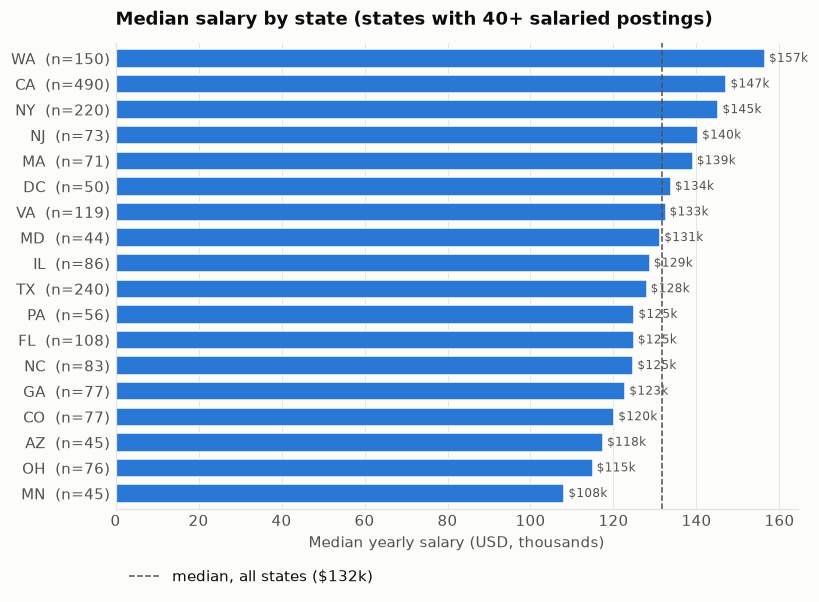

In [9]:
sal = df.dropna(subset=["salary_yearly"])
by_state = sal.groupby("state", observed=True)["salary_yearly"].agg(["median", "size"])
by_state = by_state[by_state["size"] >= 40].sort_values("median", ascending=False)
overall = sal["salary_yearly"].median()

fig, ax = plt.subplots(figsize=(8, 5.5))
viz.barh(ax, [f"{s}  (n={n})" for s, n in zip(by_state.index, by_state["size"])], by_state["median"] / 1000, fmt="${:.0f}k")
ax.axvline(overall / 1000, color=viz.TEXT_SECONDARY, linestyle="--", linewidth=1, label=f"median, all states (${overall / 1000:.0f}k)")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.1))
ax.set_title("Median salary by state (states with 40+ salaried postings)")
ax.set_xlabel("Median yearly salary (USD, thousands)")
viz.save(fig, "08_salary_by_state")
plt.show()

**Takeaway:** Washington ($157k), California ($147k) and New York ($145k) pay the highest medians. The gap between the highest and lowest state medians shown is about $49k (WA vs. MN).

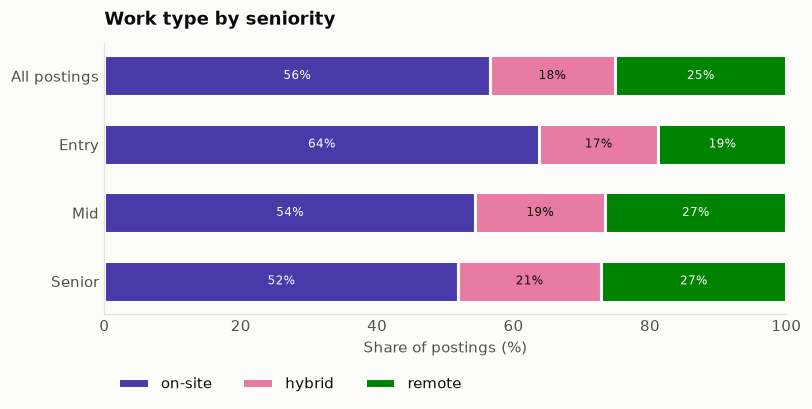

In [10]:
rows = {"All postings": df["work_type"]}
rows.update({level: df.loc[df["seniority"].eq(level), "work_type"] for level in LEVELS})
shares = pd.DataFrame({k: v.value_counts(normalize=True) for k, v in rows.items()}).T[viz.WORK_TYPE_ORDER] * 100

fig, ax = plt.subplots(figsize=(8, 3.2))
left = np.zeros(len(shares))
for wt in viz.WORK_TYPE_ORDER:
    ax.barh(shares.index, shares[wt], left=left, color=viz.WORK_TYPE_COLORS[wt], height=0.6,
            edgecolor=viz.SURFACE, linewidth=2, label=wt)
    for i, (l, v) in enumerate(zip(left, shares[wt])):
        if v >= 7:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha="center", va="center", fontsize=8, color=viz.WORK_TYPE_TEXT[wt])
    left += shares[wt].to_numpy()
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.grid(False)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.18))
ax.set_title("Work type by seniority")
ax.set_xlabel("Share of postings (%)")
viz.save(fig, "09_work_type")
plt.show()

**Takeaway:** A quarter of tech postings are remote and 18% are hybrid. Entry roles are the most on-site (64% vs. 52–54% for Mid and Senior), so remote work is less available to newcomers.

## 4. Salary

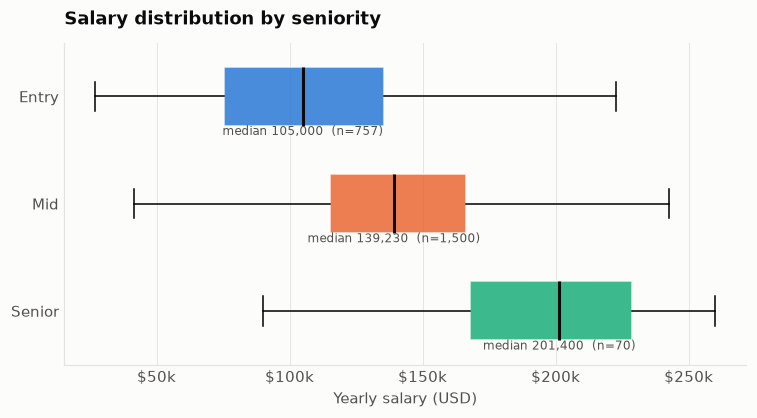

,count,25%,50%,75%
seniority,,,,
Entry,757,75458,105000,135500
Mid,1500,115000,139230,166400
Senior,70,167818,201400,228625


In [11]:
fig, ax = plt.subplots(figsize=(8, 3.8))
box_by_level(ax, "salary_yearly", "Yearly salary (USD)")
ax.xaxis.set_major_formatter(lambda x, _: f"${x / 1000:.0f}k")
ax.set_title("Salary distribution by seniority")
viz.save(fig, "10_salary_by_seniority")
plt.show()
sal_table = df.groupby("seniority", observed=True)["salary_yearly"].describe()[["count", "25%", "50%", "75%"]]
sal_table.astype(int)

**Takeaway:** Median pay rises from $105k (Entry) to $139k (Mid) to $201k (Senior). Entry and Mid ranges overlap heavily, and only 29% of postings disclose a salary.

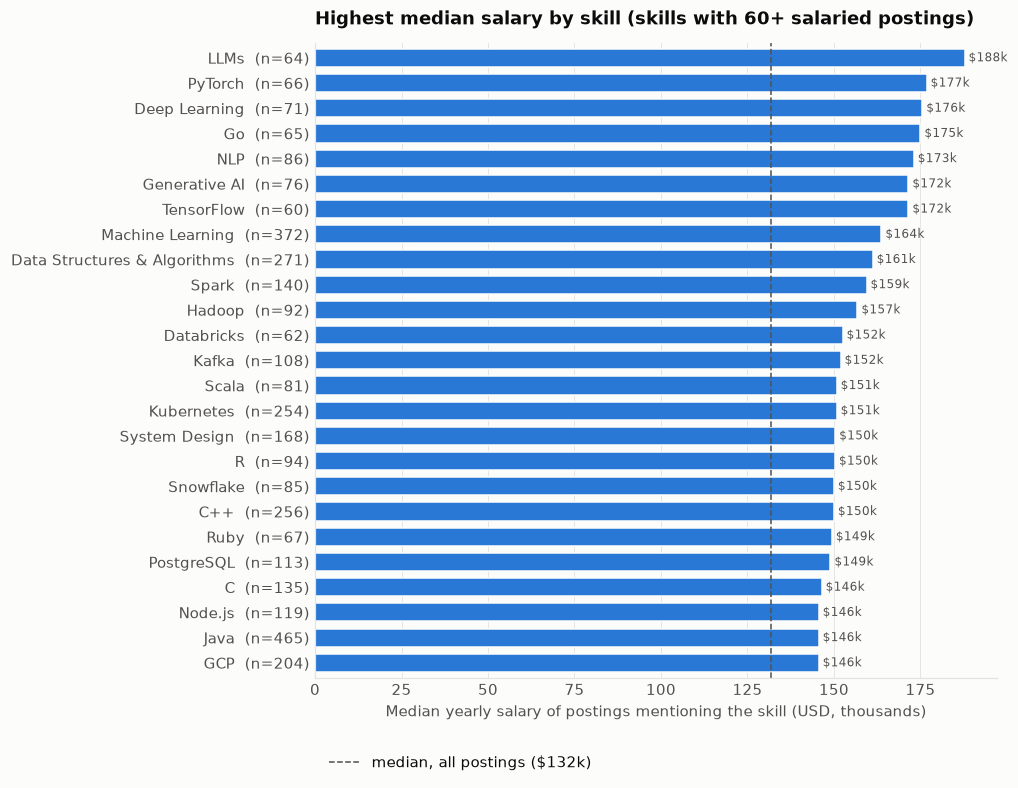

In [12]:
has_sal = df["salary_yearly"].notna()
rows = []
for skill in S.columns:
    mask = has_sal & S[skill].eq(1)
    if mask.sum() >= 60:
        rows.append({"skill": skill, "median": df.loc[mask, "salary_yearly"].median(), "n": int(mask.sum())})
skill_sal = pd.DataFrame(rows).sort_values("median", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(8, 7.5))
viz.barh(ax, [f"{s}  (n={n})" for s, n in zip(skill_sal["skill"], skill_sal["n"])], skill_sal["median"] / 1000, fmt="${:.0f}k")
ax.axvline(overall / 1000, color=viz.TEXT_SECONDARY, linestyle="--", linewidth=1, label=f"median, all postings (${overall / 1000:.0f}k)")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.1))
ax.set_title("Highest median salary by skill (skills with 60+ salaried postings)")
ax.set_xlabel("Median yearly salary of postings mentioning the skill (USD, thousands)")
viz.save(fig, "11_salary_by_skill")
plt.show()

**Takeaway:** AI/ML skills carry the highest medians: LLMs ($188k), PyTorch ($177k) and Deep Learning ($176k), about $45–55k above the overall $132k median. Go is the best-paid general-purpose language ($175k). This is correlation, not causation: these skills cluster in senior roles and high-cost locations.

## 5. Posting volume over time

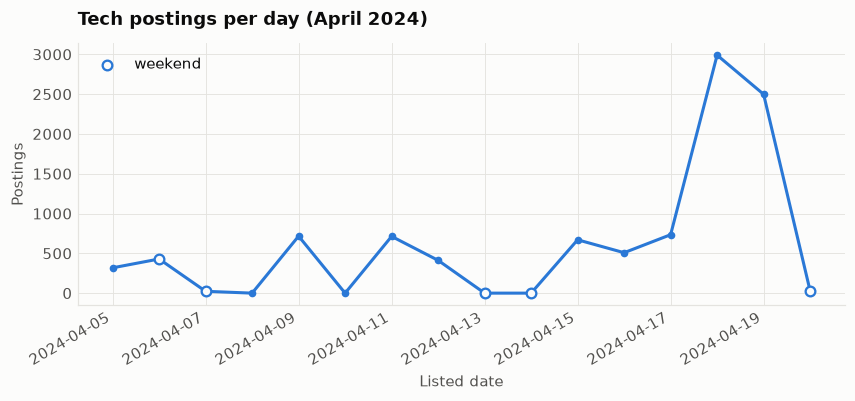

Before April: 0 postings


In [13]:
daily = df.set_index("listed_date").resample("D").size()
daily = daily[daily.index >= "2024-04-01"]
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(daily.index, daily.values, color=viz.BLUE, marker="o", markersize=4)
weekends = daily[daily.index.dayofweek >= 5]
ax.scatter(weekends.index, weekends.values, s=40, color=viz.SURFACE, edgecolor=viz.BLUE, linewidth=1.5, zorder=3, label="weekend")
ax.legend(loc="upper left")
ax.set_title("Tech postings per day (April 2024)")
ax.set_xlabel("Listed date")
ax.set_ylabel("Postings")
fig.autofmt_xdate()
viz.save(fig, "12_postings_over_time")
plt.show()
print(f"Before April: {(df['listed_date'] < '2024-04-01').sum()} postings")

**Takeaway:** The daily counts reflect when the data was collected, not hiring demand. Several days have almost no postings, and April 18–19 alone hold 55% of the dataset (5,488 postings). This snapshot cannot support claims about trends.

## 6. Distinctive words per seniority level

TF-IDF (1–2 word phrases, English stop words removed, min_df=5) on labeled descriptions. For each level we rank terms by *mean TF-IDF in that level minus mean TF-IDF in the other levels*, which gives the words that set a level apart, not just the most common words.
This is descriptive only; the model in Phase 5 fits its own vectorizer on training data.

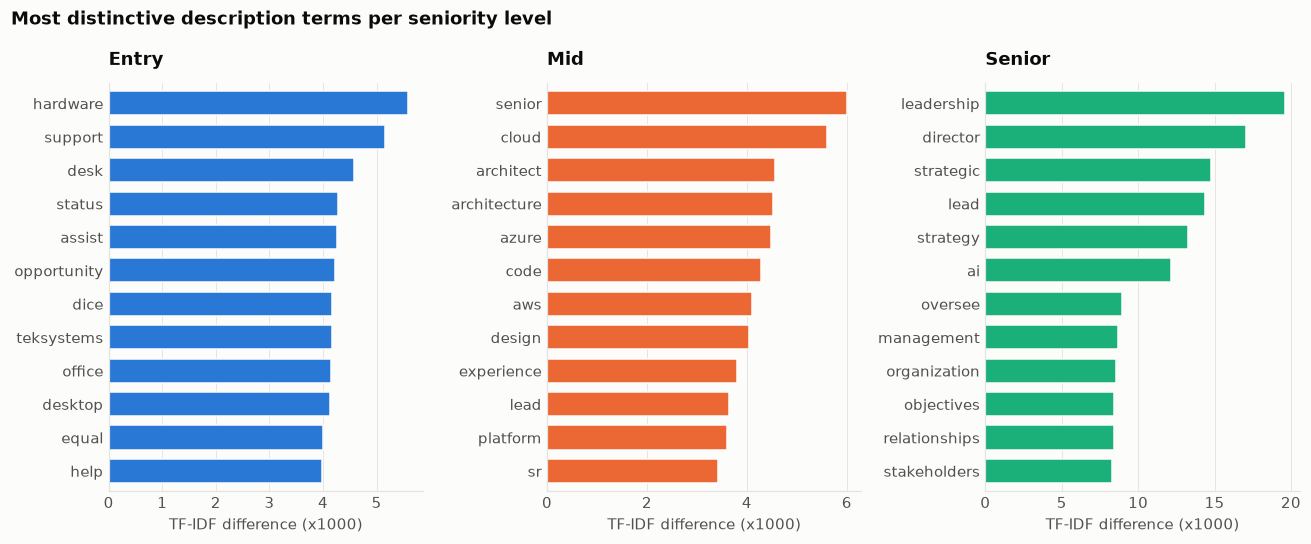

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=5, max_features=20000, sublinear_tf=True)
Xt = tfidf.fit_transform(df.loc[labeled, "description_clean"])
terms = np.array(tfidf.get_feature_names_out())
y = df.loc[labeled, "seniority"].astype(str).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, level in zip(axes, LEVELS):
    in_level = np.asarray(Xt[y == level].mean(axis=0)).ravel()
    others = np.asarray(Xt[y != level].mean(axis=0)).ravel()
    top = np.argsort(in_level - others)[::-1][:12]
    viz.barh(ax, terms[top], (in_level - others)[top] * 1000, color=viz.SENIORITY_COLORS[level], label_values=False)
    ax.set_title(level)
    ax.set_xlabel("TF-IDF difference (x1000)")
fig.suptitle("Most distinctive description terms per seniority level", x=0.01, ha="left", fontweight="bold")
fig.tight_layout()
viz.save(fig, "13_tfidf_terms")
plt.show()

**Takeaway:** Entry descriptions are dominated by IT-support words (hardware, help desk, desktop) and staffing-agency names (Dice, TEKsystems). Mid descriptions contain "senior" and "sr", which confirms that LinkedIn's Mid-Senior level mixes both. Senior descriptions are about leadership and strategy (leadership, director, strategic, stakeholders). Agency names and boilerplate could leak into the classifier, so Phase 5 should check for that.

## Key findings

- **Fundamentals beat frameworks:** SQL (27%) and Python (26%) lead, followed by Agile and cloud (AWS 21%, Azure 19%). React appears in only 7% of tech postings.
- **Skills come in stacks:** Docker → Kubernetes (66%), GCP → AWS (73%), ML → Python (64%). This is useful for the "skills you didn't mention" feature in the app.
- **AI/ML pays the most:** postings that mention LLMs, PyTorch or Deep Learning have median salaries of $176–188k, vs. $132k overall. Senior roles in high-paying states likely inflate these numbers.
- **Seniority is visible but imbalanced:** median pay goes $105k → $139k → $201k and required experience 3 → 5 → 5 years. But Senior is only 2% of postings, and 29% are unlabeled.
- **The labels are noisy:** "senior" is a top Mid term, and Entry is dominated by IT support and staffing agencies. Expect Mid/Senior confusion and possible boilerplate leakage in Phase 5.
- **Location matters:** CA and TX hold 23% of postings. WA, CA and NY pay the most (up to $157k median). Entry roles are the most on-site (64%).
- **This is a snapshot, not a trend:** 55% of postings were listed on two days in April 2024, so the data supports cross-sectional comparisons only.